Dataset: taxi_trip_pricing.csv

#### Data dictionary:

* Trip_Distance_km: The distance covered during the trip, measured in kilometers.
* Time_of_Day: The time of day the trip started (Morning, Afternoon, Evening, or Night).
* Day_of_Week: Indicates whether the trip took place on a Weekday or Weekend.
* Passenger_Count: The number of passengers in the taxi during the trip.
* Traffic_Conditions: Traffic intensity during the trip (Low, Medium, High).
* Weather: The weather condition during the trip (Clear, Rain, Snow).
* Base_Fare: The initial base fare of the taxi ride before any distance or time charges.
* Per_Km_Rate: The rate charged per kilometer of the trip.
* Per_Minute_Rate: The rate charged per minute of the trip duration.
* Trip_Duration_Minutes: The total time taken for the trip, measured in minutes.
* Trip_Price: The target variable


### Requirements:

- Data exploration
- Data visualization
- Pre-processing: Feature selection/extraction
- Linear Regression
    - Model Evaluation using Test set
    - Report

## Import library package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.analyzer import TTTH_Analyzer
from processor.feature import FeatureProcessor

In [2]:
_analyzer = TTTH_Analyzer()
_processor = FeatureProcessor()

## Read dataset and check overview

In [3]:
df = pd.read_csv('/Users/vithaovu/Documents/hocthem/exam/taxi-trip-price-prediction/data/taxi_trip_pricing.csv')

In [4]:
df.head(2)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN


In [5]:
df.tail(2)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090
999,22.85,Morning,Weekend,3.0,Medium,Clear,4.34,NaN,0.23,29.69,45.4437


In [6]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


* Seem that df.info() can not detect missing value in dataframe, need to use isnull().sum()

In [8]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

* Seem all columns have missing value need to handle before next step
* All columns seem related with Trip_Price, no need to drop

## Preprocessing

### Remove duplicates

In [9]:
df.duplicated().any()

False

* There is no duplicated value

### Handle missing variables

In [10]:
print("Trip_Distance_km before fill missing values:", df['Trip_Distance_km'].isna().sum())
df['Trip_Distance_km'] = df['Trip_Distance_km'].fillna(df['Trip_Distance_km'].median())
print("Trip_Distance_km after fill missing values:", df['Trip_Distance_km'].isna().sum())

Trip_Distance_km before fill missing values: 50
Trip_Distance_km after fill missing values: 0


In [11]:
print("\nTime_of_Day before fill missing values:", df['Time_of_Day'].isna().sum())
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
print("Time_of_Day after fill missing values:", df['Time_of_Day'].isna().sum())


Time_of_Day before fill missing values: 50
Time_of_Day after fill missing values: 0


In [12]:
print("\nDay_of_Week before fill missing values:", df['Day_of_Week'].isna().sum())
df['Day_of_Week'] = df['Day_of_Week'].fillna(df['Day_of_Week'].mode()[0])
print("Day_of_Week after fill missing values:", df['Day_of_Week'].isna().sum())


Day_of_Week before fill missing values: 50
Day_of_Week after fill missing values: 0


In [13]:
print("\nPassenger_Count before fill missing values:", df['Passenger_Count'].isna().sum())
df['Passenger_Count'] = df['Passenger_Count'].fillna(df['Passenger_Count'].median())
print("Passenger_Count after fill missing values:", df['Passenger_Count'].isna().sum())


Passenger_Count before fill missing values: 50
Passenger_Count after fill missing values: 0


In [14]:
print("\nTraffic_Conditions before fill missing values:", df['Traffic_Conditions'].isna().sum())
df['Traffic_Conditions'] = df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0])
print("Traffic_Conditions after fill missing values:", df['Traffic_Conditions'].isna().sum())


Traffic_Conditions before fill missing values: 50
Traffic_Conditions after fill missing values: 0


In [15]:
print("Weather before fill missing values:", df['Weather'].isna().sum())
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
print("Weather after fill missing values:", df['Weather'].isna().sum())

Weather before fill missing values: 50
Weather after fill missing values: 0


In [16]:
print("\nBase_Fare before fill missing values:", df['Base_Fare'].isna().sum())
df['Base_Fare'] = df['Base_Fare'].fillna(df['Base_Fare'].median())
print("Base_Fare after fill missing values:", df['Base_Fare'].isna().sum())


Base_Fare before fill missing values: 50
Base_Fare after fill missing values: 0


In [17]:
print("\nPer_Km_Rate before fill missing values:", df['Per_Km_Rate'].isna().sum())
df['Per_Km_Rate'] = df['Per_Km_Rate'].fillna(df['Per_Km_Rate'].median())
print("Per_Km_Rate after fill missing values:", df['Per_Km_Rate'].isna().sum())


Per_Km_Rate before fill missing values: 50
Per_Km_Rate after fill missing values: 0


In [18]:
print("\nPer_Minute_Rate before fill missing values:", df['Per_Minute_Rate'].isna().sum())
df['Per_Minute_Rate'] = df['Per_Minute_Rate'].fillna(df['Per_Minute_Rate'].median())
print("Per_Minute_Rate after fill missing values:", df['Per_Minute_Rate'].isna().sum())


Per_Minute_Rate before fill missing values: 50
Per_Minute_Rate after fill missing values: 0


In [19]:
print("\nTrip_Duration_Minutes before fill missing values:", df['Trip_Duration_Minutes'].isna().sum())
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(df['Trip_Duration_Minutes'].median())
print("Trip_Duration_Minutes after fill missing values:", df['Trip_Duration_Minutes'].isna().sum())


Trip_Duration_Minutes before fill missing values: 50
Trip_Duration_Minutes after fill missing values: 0


In [20]:
df = df.dropna(subset=['Trip_Price']).reset_index(drop=True)

In [21]:
df['Trip_Price'].isna().sum()

0

In [22]:
df.shape  

(951, 11)

## Identify variable

As requirement, predict `Trip_Price` so
* Output variable: Trip_Price
* Input variable: 
    * Trip_Distance_km -> numeric
    * Time_of_Day -> category
    * Day_of_Week -> caterogy
    * Passenger_Count -> numeric
    * Traffic_Conditions -> category (ordinal)
    * Weather -> caterogy (ordinal)
    * Base_Fare -> numeric
    * Per_Km_Rate -> numeric
    * Per_Minute_Rate -> numeric
    * Trip_Duration_Minutes -> Numeric

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       951 non-null    float64
 1   Time_of_Day            951 non-null    object 
 2   Day_of_Week            951 non-null    object 
 3   Passenger_Count        951 non-null    float64
 4   Traffic_Conditions     951 non-null    object 
 5   Weather                951 non-null    object 
 6   Base_Fare              951 non-null    float64
 7   Per_Km_Rate            951 non-null    float64
 8   Per_Minute_Rate        951 non-null    float64
 9   Trip_Duration_Minutes  951 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 81.9+ KB


In [24]:
df.head(5)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
2,30.33,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
3,25.83,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
4,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


### Split into numeric and category dataframe to analyze

In [25]:
df_out = df[['Trip_Price']]

In [26]:
df_in = df.drop('Trip_Price',axis=1)

In [27]:
df_in_cat = df_in.select_dtypes(include='O')

In [28]:
df_in_num = df_in.select_dtypes(exclude='O')

In [29]:
df_in_cat.head(5)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
0,Morning,Weekday,Low,Clear
1,Evening,Weekend,High,Clear
2,Evening,Weekday,Low,Clear
3,Evening,Weekday,High,Clear
4,Afternoon,Weekend,Medium,Clear


In [30]:
df_in_num.head(5)

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes
0,19.35,3.0,3.56,0.80,0.32,53.82
1,36.87,1.0,2.70,1.21,0.15,37.27
2,30.33,4.0,3.48,0.51,0.15,116.81
3,25.83,3.0,2.93,0.63,0.32,22.64
4,8.64,2.0,2.55,1.71,0.48,89.33


## Univariate analysis

### Input Category analysis

In [31]:
df_in_cat.columns

Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='object')

In [32]:
def eda_uni_category_analysis_sns(df, col_name):
    count_cat = df[col_name].value_counts().reset_index()
    count_cat.columns = [col_name, "Count"]

    print(f"\nClass count of {col_name}:")
    print(count_cat)

    plt.figure(figsize=(6,4))
    sns.barplot(data=count_cat, x=col_name, y="Count")
    plt.title(f"Bar chart of {col_name}")
    plt.show()


Class count of Time_of_Day:
  Time_of_Day  Count
0   Afternoon    400
1     Morning    265
2     Evening    197
3       Night     89


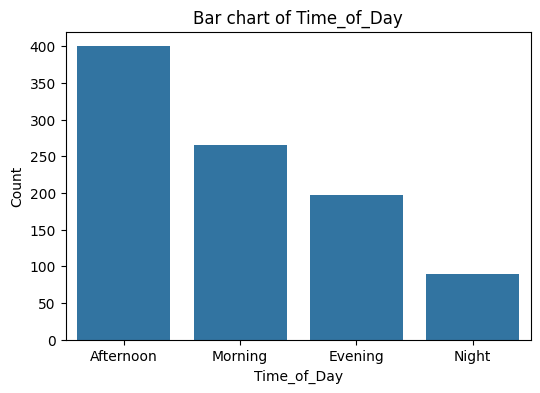

In [33]:
eda_uni_category_analysis_sns(df, "Time_of_Day")

What is top `Time_of_Day` user refer taxi?

=> Thời điểm mà người dùng gọi taxi nhiều nhất là Afternoon (chiều) với 400 lượt.


Class count of Day_of_Week:
  Day_of_Week  Count
0     Weekday    668
1     Weekend    283


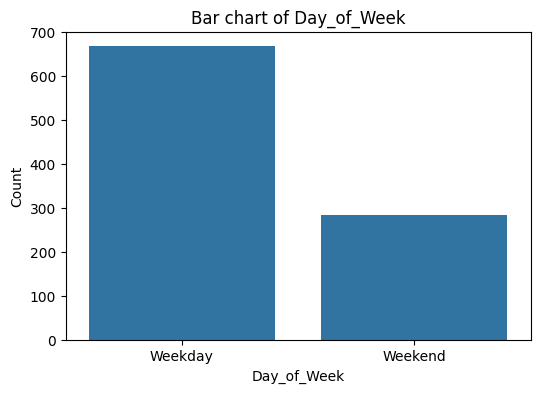

In [34]:
eda_uni_category_analysis_sns(df, "Day_of_Week")

People refer taxi in weekday or weekend? can you explain?

=> Người dùng đi taxi nhiều hơn vào các ngày trong tuần (Weekday: 668 lượt) so với cuối tuần (Weekend: 283 lượt).
=> Các ngày trong tuần mọi người cần đi làm, đi học, gặp đối tác,... nên nhu cầu đi lại bằng taxi nhiều hơn so với cuối tuần và cuối tuần thì sử dụng taxi vì có nhiều ngườ sẽ nghỉ ngơi ở nhà.


Class count of Traffic_Conditions:
  Traffic_Conditions  Count
0                Low    424
1             Medium    355
2               High    172


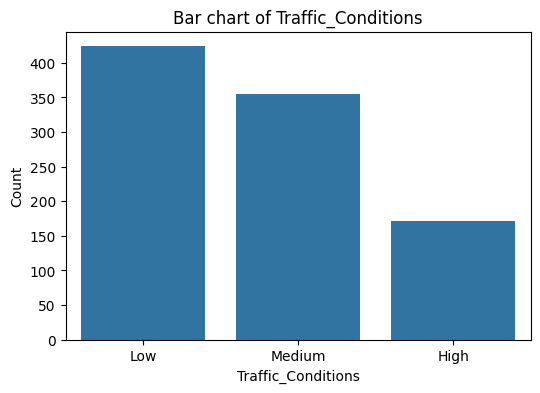

In [35]:
eda_uni_category_analysis_sns(df, "Traffic_Conditions")

People refer to use taxi in what `Traffic_Conditions`?

=> Thời điểm mà người dùng gọi taxi nhiều nhất là Afternoon (chiều) với 400 lượt.


Class count of Weather:
  Weather  Count
0   Clear    680
1    Rain    216
2    Snow     55


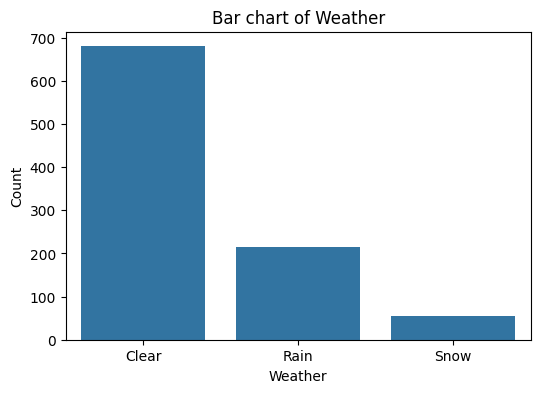

In [36]:
eda_uni_category_analysis_sns(df, "Weather")

People refer to use taxi in what kind of weather? 

=> Người ta gọi taxi nhiều nhất khi trời quang đãng, ít hơn khi mưa và rất ít khi có tuyết.

### Preprocessing

* Do we need any further preprocessing step?

### Input Numerical analysis

In [37]:
df_in_num.columns

Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes'],
      dtype='object')

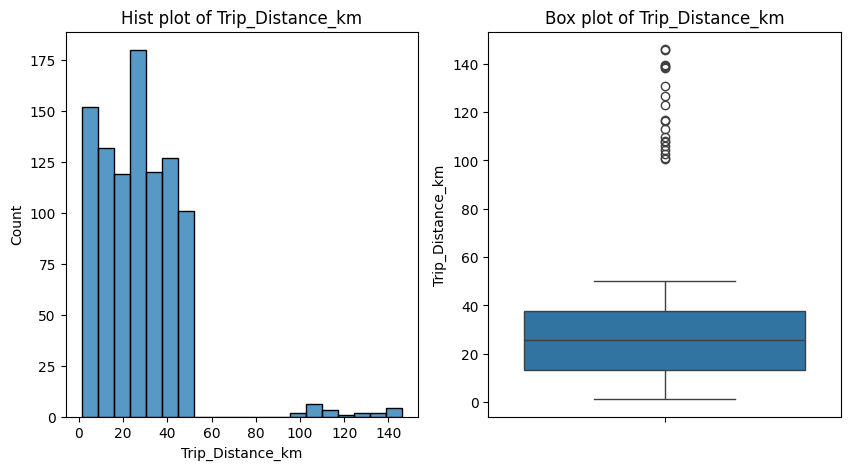

In [38]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Trip_Distance_km'], bins=20, kde=False)
plt.title("Hist plot of Trip_Distance_km")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Trip_Distance_km'])
plt.title("Box plot of Trip_Distance_km")
plt.show()

`Trip_Distance_km` have outlier or not? what is it distribution? 

=>Trip_Distance_km có outlier.Và phân phối của nó là lệch phải.

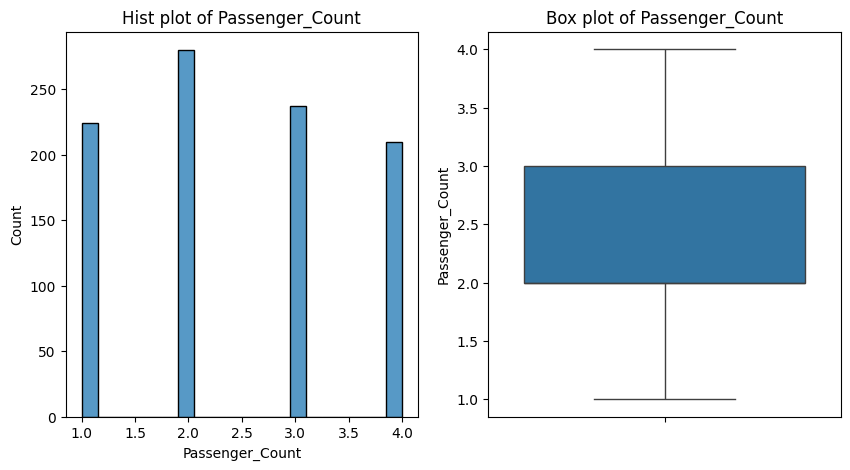

In [39]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Passenger_Count'], bins=20, kde=False)
plt.title("Hist plot of Passenger_Count")
plt.subplot(1,2,2)
sns.boxplot(y=df['Passenger_Count'])
plt.title("Box plot of Passenger_Count")
plt.show()

`Passenger_Count` have outlier or not?

=> Passenger_Count không có outlier.

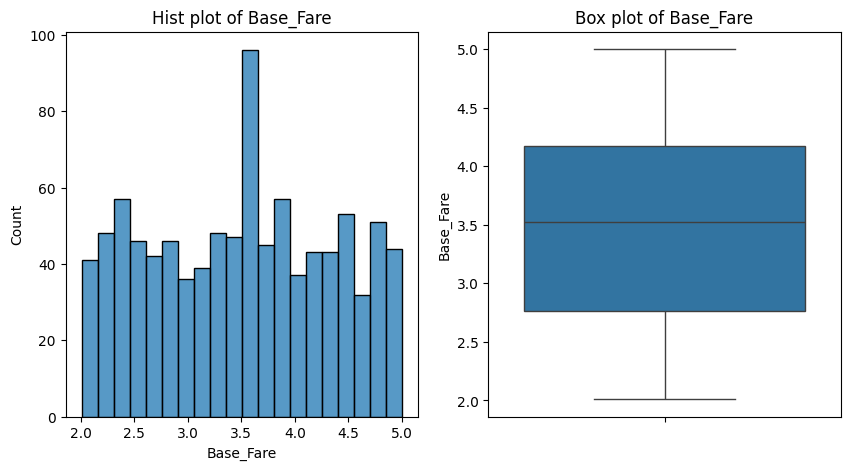

In [40]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Base_Fare'], bins=20, kde=False)
plt.title("Hist plot of Base_Fare")
plt.subplot(1,2,2)
sns.boxplot(y=df['Base_Fare'])
plt.title("Box plot of Base_Fare")
plt.show()

Comment on `Base_Fare`

=> Biến Base_Fare phân bố khá đồng đều, tập trung nhiều ở mức 3.5, không có outlier.

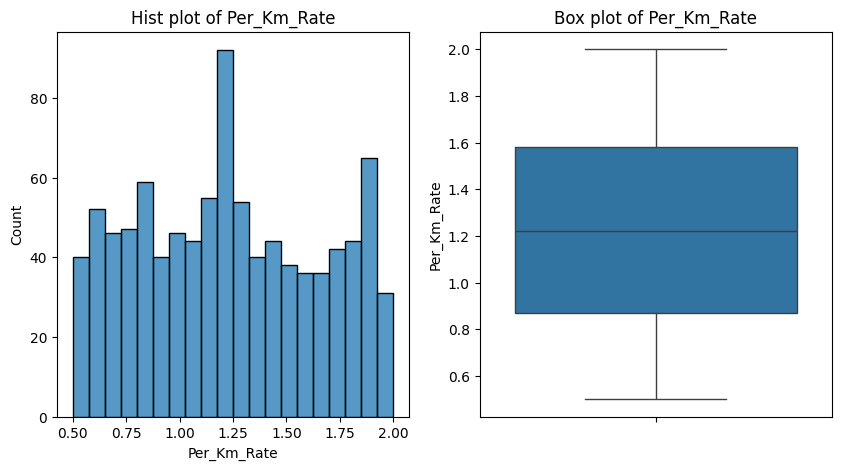

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Per_Km_Rate'], bins=20, kde=False)
plt.title("Hist plot of Per_Km_Rate")
plt.subplot(1,2,2)
sns.boxplot(y=df['Per_Km_Rate'])
plt.title("Box plot of Per_Km_Rate")
plt.show()

Comment on `Per_Km_Rate`

=>Biến Per_Km_Rate phân bố tập trung quanh 1.2, không có outlier, phân bố khá đồng đều và cân đối.

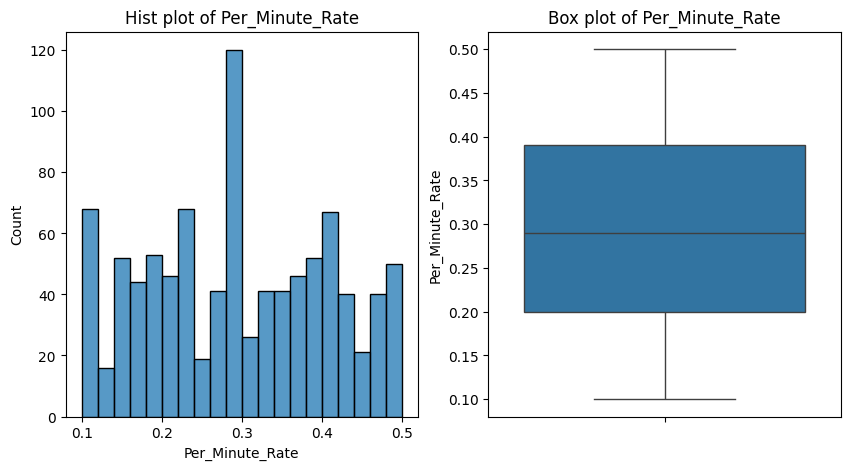

In [42]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Per_Minute_Rate'], bins=20, kde=False)
plt.title("Hist plot of Per_Minute_Rate")
plt.subplot(1,2,2)
sns.boxplot(y=df['Per_Minute_Rate'])
plt.title("Box plot of Per_Minute_Rate")
plt.show()

Comment on `Per_Minute_Rate`

=> Biến Per_Minute_Rate phân bố khá đồng đều, trung vị ở 0.3, không có outlier, phần lớn giá trị tập trung quanh 0.3.

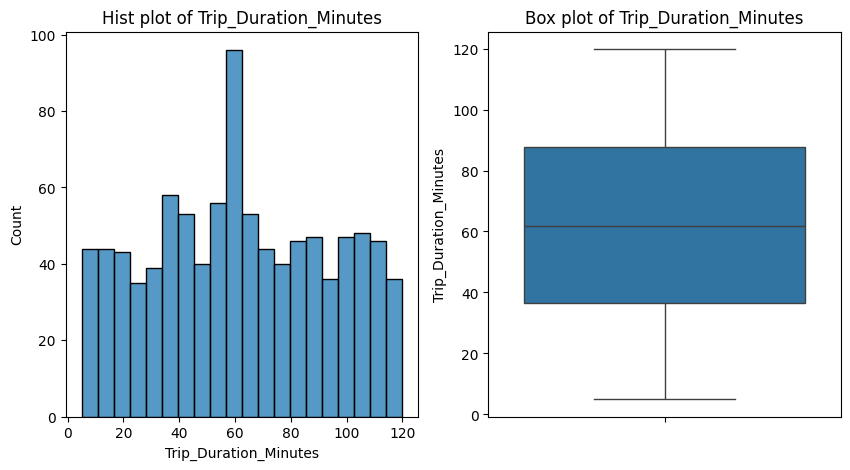

In [43]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Trip_Duration_Minutes'], bins=20, kde=False)
plt.title("Hist plot of Trip_Duration_Minutes")
plt.subplot(1,2,2)
sns.boxplot(y=df['Trip_Duration_Minutes'])
plt.title("Box plot of Trip_Duration_Minutes")
plt.show()

Comment on `Trip_Duration_Minutes`

=>Trip_Duration_Minutes phân bố khá đồng đều, median ~60 phút, không có outlier

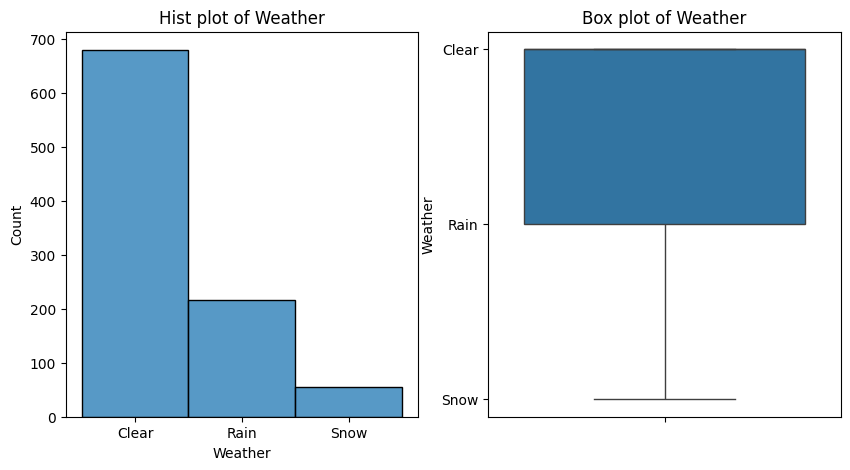

In [44]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Weather'], bins=20, kde=False)
plt.title("Hist plot of Weather")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Weather'])
plt.title("Box plot of Weather")
plt.savefig("images/weather_distribution.png",
            bbox_inches='tight')
plt.show()

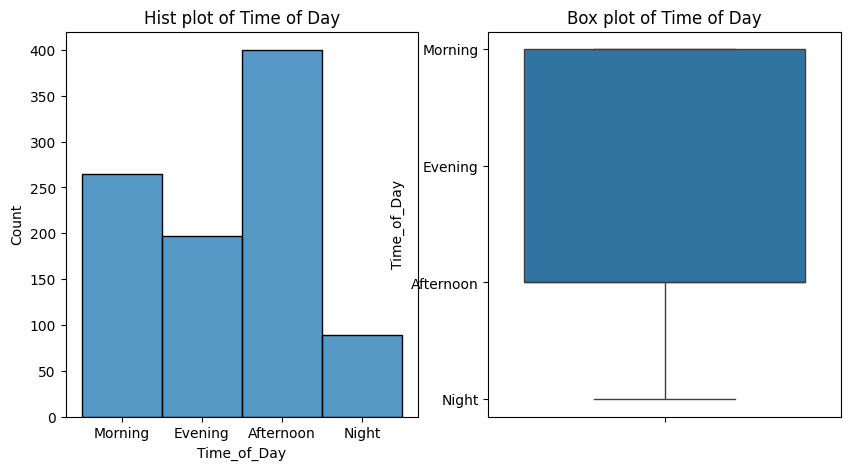

In [45]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Time_of_Day'], bins=20, kde=False)
plt.title("Hist plot of Time of Day")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Time_of_Day'])
plt.title("Box plot of Time of Day")
plt.savefig("images/time_of_day_distribution.png",
            bbox_inches='tight')
plt.show()

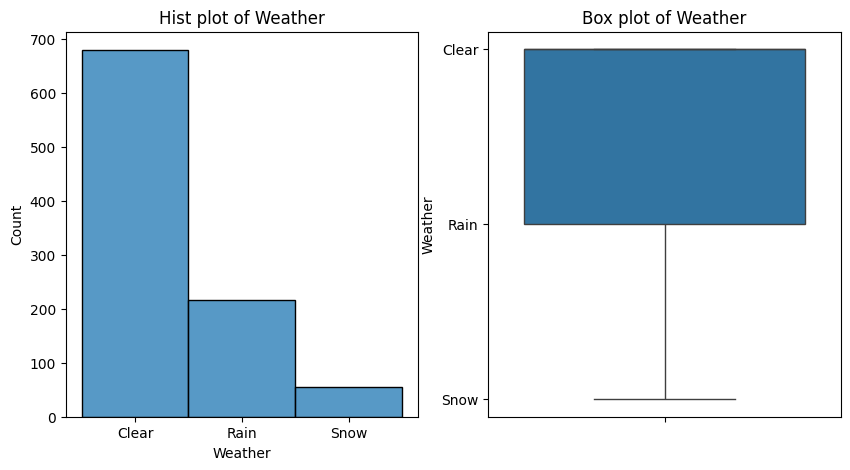

In [46]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Weather'], bins=20, kde=False)
plt.title("Hist plot of Weather")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Weather'])
plt.title("Box plot of Weather")
plt.savefig("images/weather_distribution.png",
            bbox_inches='tight')
plt.show()

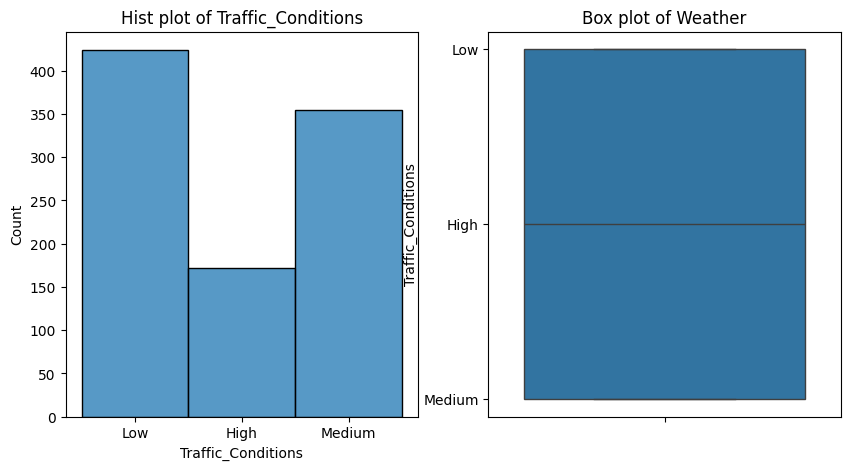

In [47]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Traffic_Conditions'], bins=20, kde=False)
plt.title("Hist plot of Traffic_Conditions")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Traffic_Conditions'])
plt.title("Box plot of Weather")
plt.savefig("images/traffic_conditions_distribution.png",
            bbox_inches='tight')
plt.show()

### Output Numerical analysis

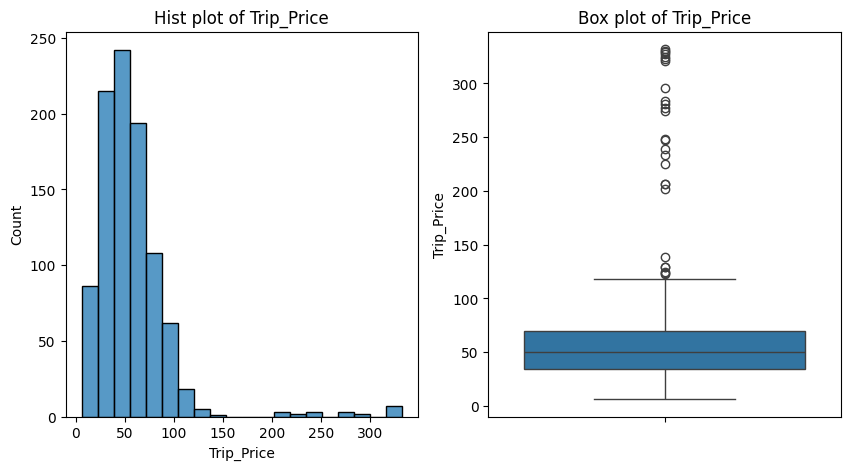

In [48]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data =  df['Trip_Price'], bins=20, kde=False)
plt.title("Hist plot of Trip_Price")
plt.subplot(1,2,2)
sns.boxplot(data =  df['Trip_Price'])
plt.title("Box plot of Trip_Price")
plt.savefig("images/trip_price_distribution.png",
            bbox_inches='tight')
plt.show()

Comment on `Trip_Price`

=> Trip_Price tập trung trong khoảng 30–70, nhưng có rất nhiều outlier lớn → dữ liệu phân bố lệch phải, cần xem xét xử lý outlier khi phân tích

## Bi-variate analysis

### Handle uncommon category

* Do we need to handle uncommon category for any variable?

### Continuous vs Continuous (Input and Output)

In [49]:
df_corr = pd.concat([df_in_num, df_out], axis=1).corr()
df_corr

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.041689,0.032517,-0.012808,-0.033396,-0.023419,0.841829
Passenger_Count,-0.041689,1.000000,0.024501,0.039461,0.038119,0.019514,-0.013172
Base_Fare,0.032517,0.024501,1.000000,0.001072,-0.017268,0.009521,0.035165
Per_Km_Rate,-0.012808,0.039461,0.001072,1.000000,0.024912,0.028212,0.263500
Per_Minute_Rate,-0.033396,0.038119,-0.017268,0.024912,1.000000,-0.022578,0.133910
Trip_Duration_Minutes,-0.023419,0.019514,0.009521,0.028212,-0.022578,1.000000,0.219335
Trip_Price,0.841829,-0.013172,0.035165,0.263500,0.133910,0.219335,1.000000


* `Trip_Distance_km` have high correlation with `Trip_Price`
* Others variable seem independ with `Trip_Price`

=>Trip_Distance_km có hệ số tương quan cao với Trip_Price (~0.84). Nghĩa là quãng đường càng xa thì giá chuyến đi càng dài (hợp lý).
=> Các biến khác (Passenger_Count, Base_Fare, Per_Km_Rate, Per_Minute_Rate, Trip_Duration_Minutes) có hệ số tương quan rất nhỏ với Trip_Price.Nghĩa là gần như độc lập, ít ảnh hưởng trực tiếp đến giá chuyến đi.

### Input Category vs Input Category 

In [50]:
categories = _analyzer.create_unique_pair_variable(df_in_cat.columns)
categories

[{'Day_of_Week', 'Time_of_Day'},
 {'Time_of_Day', 'Traffic_Conditions'},
 {'Time_of_Day', 'Weather'},
 {'Day_of_Week', 'Traffic_Conditions'},
 {'Day_of_Week', 'Weather'},
 {'Traffic_Conditions', 'Weather'}]

=====Analyze of Day_of_Week and Time_of_Day=====


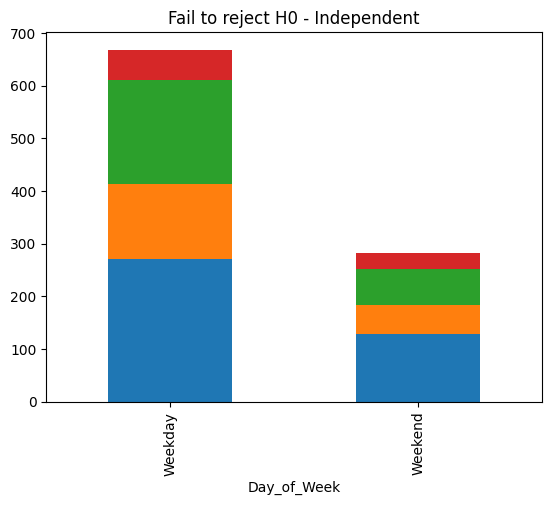

=====Analyze of Time_of_Day and Traffic_Conditions=====


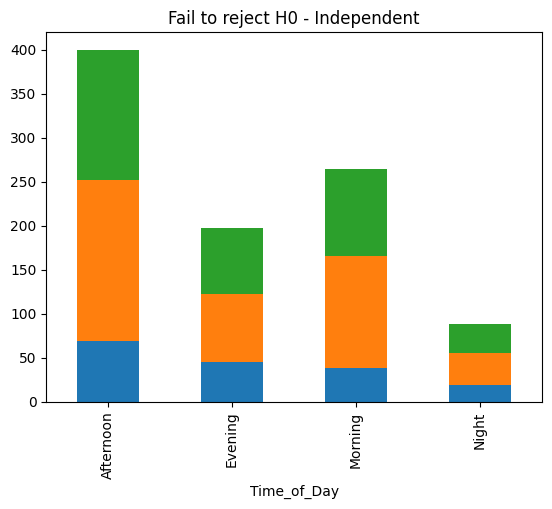

=====Analyze of Time_of_Day and Weather=====


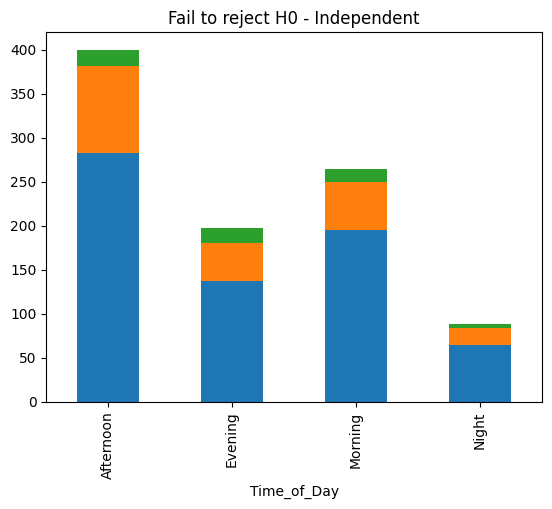

=====Analyze of Day_of_Week and Traffic_Conditions=====


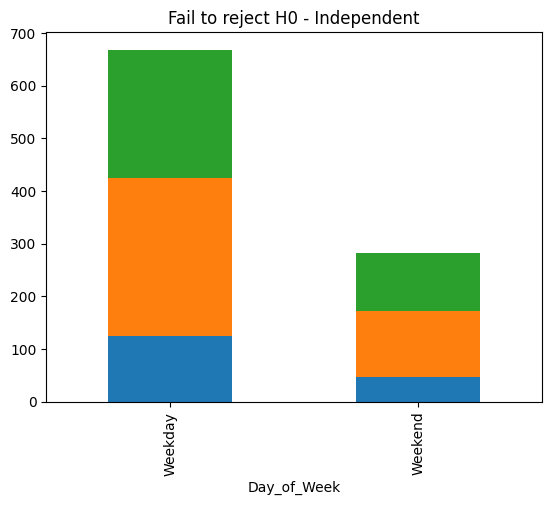

=====Analyze of Day_of_Week and Weather=====


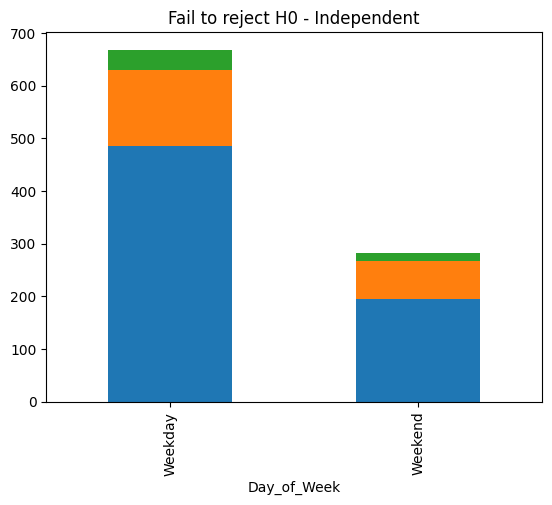

=====Analyze of Traffic_Conditions and Weather=====


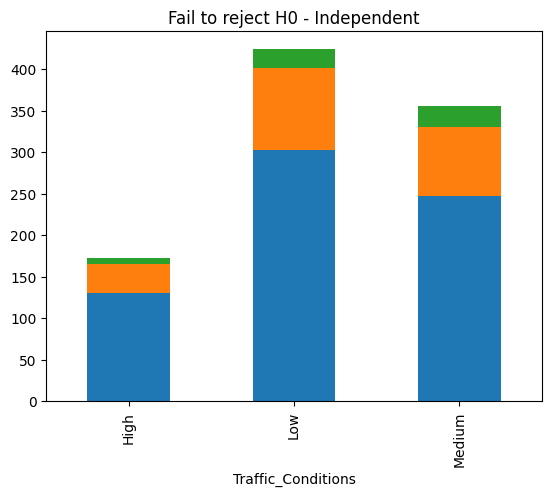

In [51]:
results = []
for cat1 ,cat2 in categories:
    result = _analyzer.analyze_category_vs_category(cat1,cat2,df_in_cat)
    results.append(result)

In [52]:
pd.DataFrame(results)

,var1,var2,result
0,Day_of_Week,Time_of_Day,Fail to reject H0 - Independent
1,Time_of_Day,Traffic_Conditions,Fail to reject H0 - Independent
2,Time_of_Day,Weather,Fail to reject H0 - Independent
3,Day_of_Week,Traffic_Conditions,Fail to reject H0 - Independent
4,Day_of_Week,Weather,Fail to reject H0 - Independent
5,Traffic_Conditions,Weather,Fail to reject H0 - Independent


* Seem that all category variable have Independent with others

### Output Continuous vs Input Category 

In [53]:
df_in_cat.columns

Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='object')

                      sum_sq     df        F    PR(>F)
C(Time_of_Day)  6.769984e+02    3.0  0.13741  0.937678
Residual        1.555237e+06  947.0      NaN       NaN


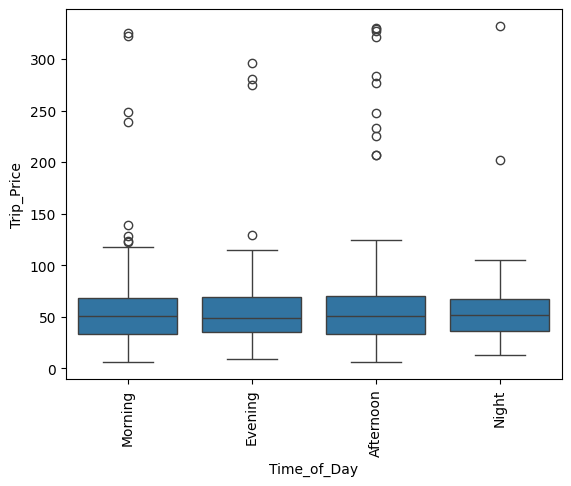

In [54]:
_analyzer.analyze_continous_vs_categories(continous_var='Trip_Price',category_vars='Time_of_Day',df=df)

`Time_of_Day` have any relation or impact to `Trip_Price` or not?

=> PR(>F) = 0.937678 (> 0.05) chấp nhận H0 .Time_of_Day không có tác động đáng kể đến Trip_Price

                      sum_sq     df        F    PR(>F)
C(Day_of_Week)  1.413121e+03    1.0  0.86269  0.353223
Residual        1.554501e+06  949.0      NaN       NaN


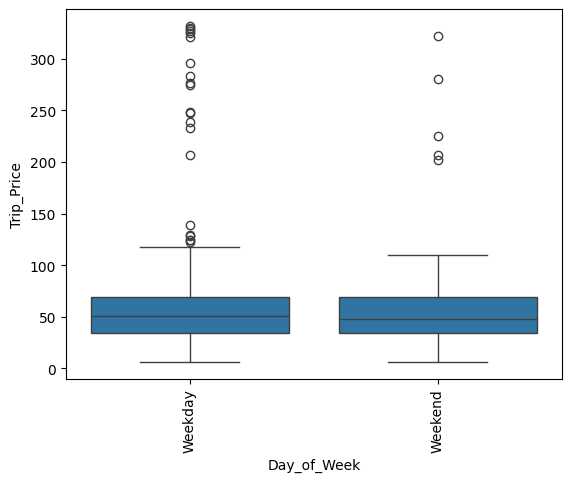

In [55]:
_analyzer.analyze_continous_vs_categories('Trip_Price','Day_of_Week',df=df)

`Day_of_Week` have any relation or impact to `Trip_Price` or not?

=> PR(>F) = 0.353223 (> 0.05)  chấp nhận H0 .Day_of_Week không có tác động đáng kể đến Trip_Price

                             sum_sq     df        F    PR(>F)
C(Traffic_Conditions)  1.424283e+04    2.0  4.37908  0.012791
Residual               1.541671e+06  948.0      NaN       NaN


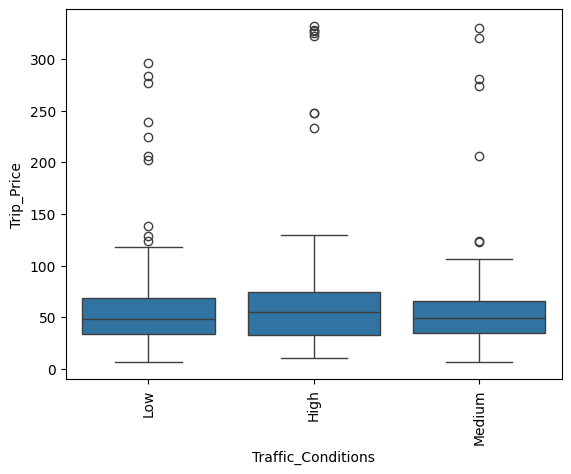

In [56]:
_analyzer.analyze_continous_vs_categories('Trip_Price','Traffic_Conditions',df=df)

`Traffic_Conditions` have any relation or impact to `Trip_Price` or not?

=>PR(>F) = 0.012791 (< 0.05) bác bỏ H0 chấp nhận Ha.Traffic_Conditions có tác động đáng kể đến Trip_Price

                  sum_sq     df         F    PR(>F)
C(Weather)  2.532318e+03    2.0  0.772713  0.462049
Residual    1.553381e+06  948.0       NaN       NaN


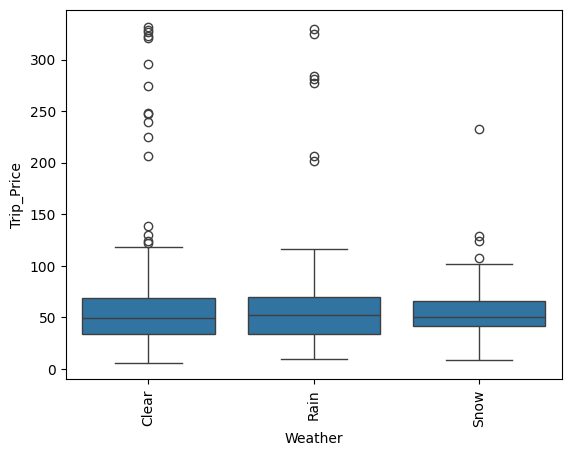

In [57]:
_analyzer.analyze_continous_vs_categories('Trip_Price','Weather',df=df)

`Weather` have any relation or impact to `Trip_Price` or not?

=>PR(>F) = 0.462049 (> 0.05) chấp nhận H0 .Weather không có tác động đáng kể đến Trip_Price

### Input Category vs Input Continuous 

In [58]:
num_col =  df_in_num.columns.to_list()
num_col

['Trip_Distance_km',
 'Passenger_Count',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes']

In [59]:
cat_col = df_in_cat.columns.to_list()
cat_col

['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

In [60]:
df_cat_num = pd.concat([df_in_num, df_in_cat], axis=1)

In [61]:
df_cat_num.head(5)

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
0,19.35,3.0,3.56,0.80,0.32,53.82,Morning,Weekday,Low,Clear
1,36.87,1.0,2.70,1.21,0.15,37.27,Evening,Weekend,High,Clear
2,30.33,4.0,3.48,0.51,0.15,116.81,Evening,Weekday,Low,Clear
3,25.83,3.0,2.93,0.63,0.32,22.64,Evening,Weekday,High,Clear
4,8.64,2.0,2.55,1.71,0.48,89.33,Afternoon,Weekend,Medium,Clear


                       sum_sq     df         F    PR(>F)
C(Time_of_Day)    1004.719086    3.0  0.869661  0.456304
Residual        364689.510255  947.0       NaN       NaN


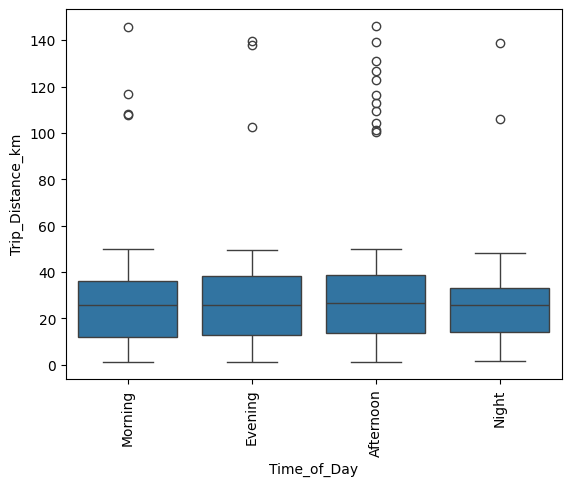

                     sum_sq     df         F    PR(>F)
C(Time_of_Day)     3.315577    3.0  0.951008  0.415297
Residual        1100.535106  947.0       NaN       NaN


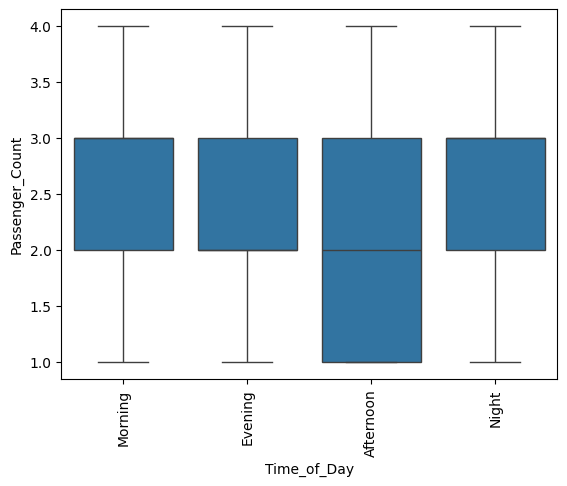

                    sum_sq     df         F   PR(>F)
C(Time_of_Day)    1.161045    3.0  0.539399  0.65539
Residual        679.465634  947.0       NaN      NaN


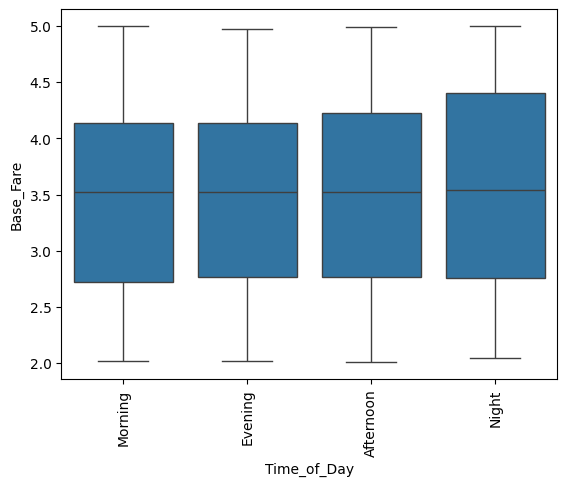

                    sum_sq     df        F    PR(>F)
C(Time_of_Day)    1.153900    3.0  2.18982  0.087702
Residual        166.336837  947.0      NaN       NaN


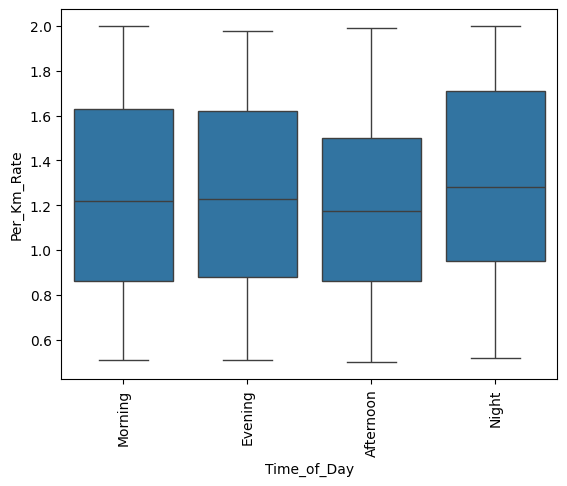

                   sum_sq     df         F    PR(>F)
C(Time_of_Day)   0.037170    3.0  0.980777  0.401076
Residual        11.963201  947.0       NaN       NaN


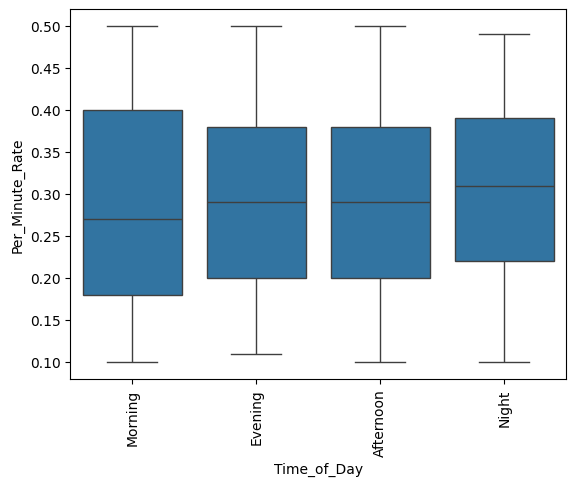

                       sum_sq     df         F    PR(>F)
C(Time_of_Day)    4718.576870    3.0  1.585115  0.191374
Residual        939677.636252  947.0       NaN       NaN


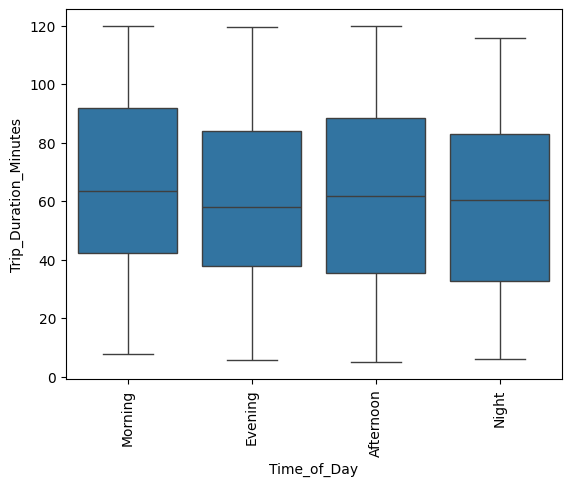

In [62]:
for num in num_col:
    _analyzer.analyze_continous_vs_categories(num,'Time_of_Day',df=df_cat_num)

                       sum_sq     df         F    PR(>F)
C(Day_of_Week)     160.374770    1.0  0.416365  0.518912
Residual        365533.854571  949.0       NaN       NaN


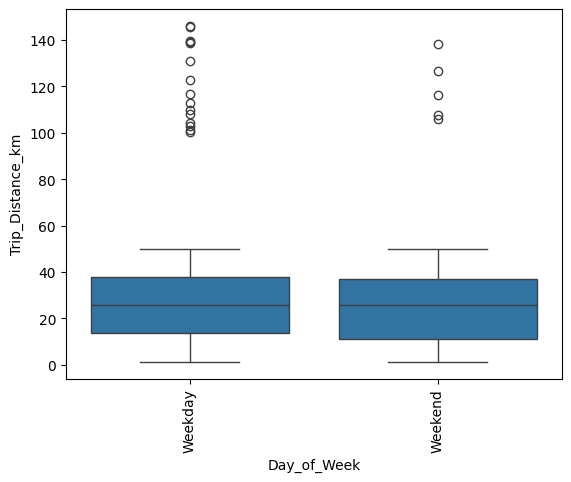

                     sum_sq     df         F    PR(>F)
C(Day_of_Week)     0.333915    1.0  0.287159  0.592172
Residual        1103.516769  949.0       NaN       NaN


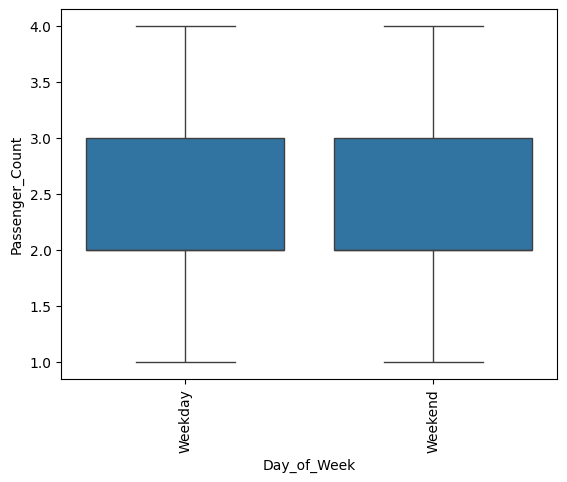

                    sum_sq     df         F    PR(>F)
C(Day_of_Week)    0.470329    1.0  0.656235  0.418096
Residual        680.156351  949.0       NaN       NaN


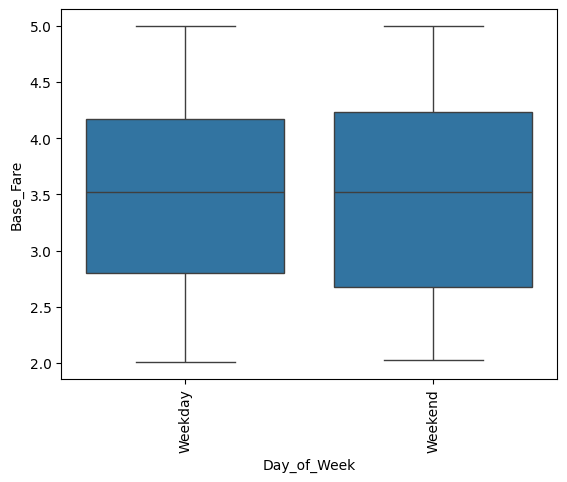

                    sum_sq     df        F    PR(>F)
C(Day_of_Week)    0.345823    1.0  1.96348  0.161469
Residual        167.144915  949.0      NaN       NaN


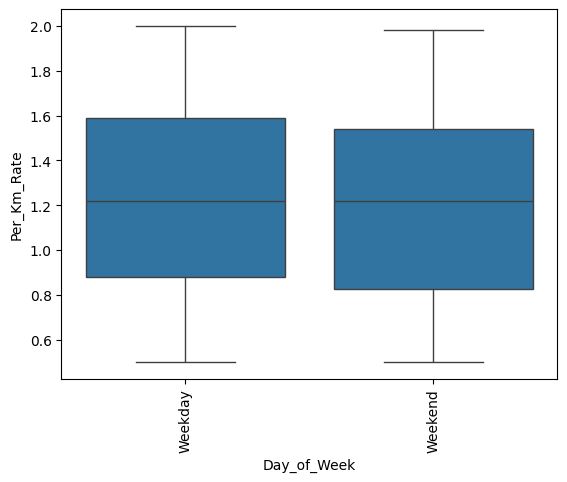

                   sum_sq     df         F    PR(>F)
C(Day_of_Week)   0.001766    1.0  0.139685  0.708678
Residual        11.998605  949.0       NaN       NaN


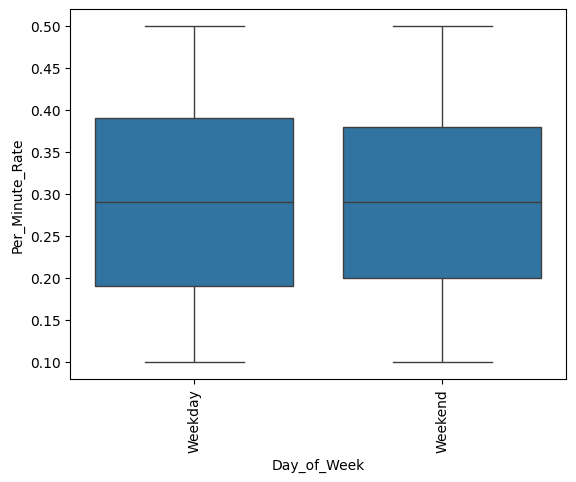

                       sum_sq     df         F    PR(>F)
C(Day_of_Week)       0.622272    1.0  0.000625  0.980055
Residual        944395.590850  949.0       NaN       NaN


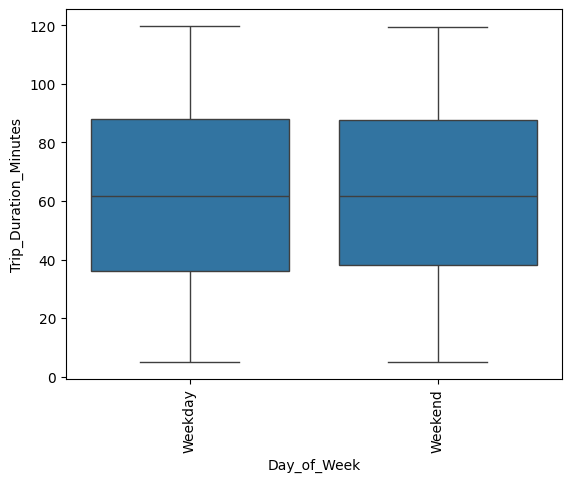

In [63]:
for num in num_col:
    _analyzer.analyze_continous_vs_categories(num,'Day_of_Week',df=df_cat_num)

                              sum_sq     df         F    PR(>F)
C(Traffic_Conditions)    4423.900380    2.0  5.804321  0.003123
Residual               361270.328961  948.0       NaN       NaN


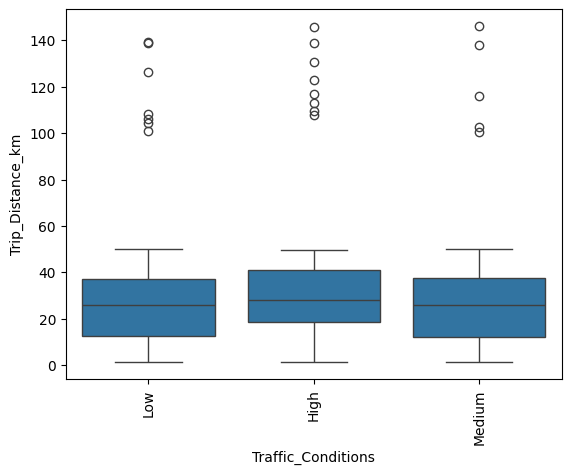

                            sum_sq     df         F    PR(>F)
C(Traffic_Conditions)     0.053028    2.0  0.022772  0.977486
Residual               1103.797655  948.0       NaN       NaN


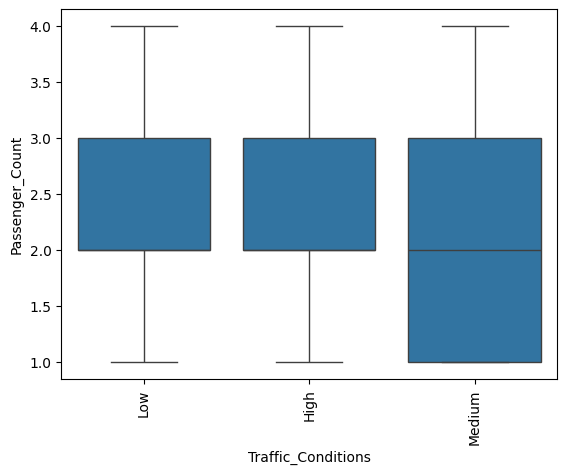

                          sum_sq     df         F    PR(>F)
C(Traffic_Conditions)    0.64150    2.0  0.447173  0.639568
Residual               679.98518  948.0       NaN       NaN


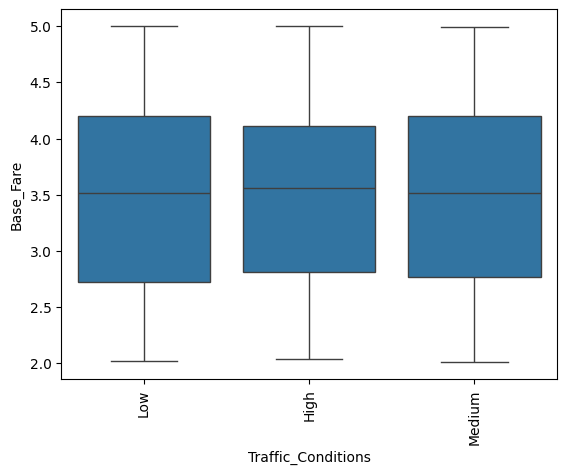

                           sum_sq     df         F    PR(>F)
C(Traffic_Conditions)    0.520288    2.0  1.477007  0.228845
Residual               166.970449  948.0       NaN       NaN


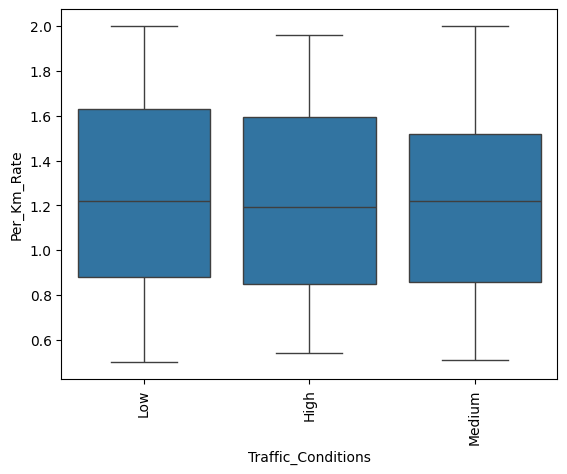

                          sum_sq     df        F   PR(>F)
C(Traffic_Conditions)   0.011146    2.0  0.44065  0.64375
Residual               11.989226  948.0      NaN      NaN


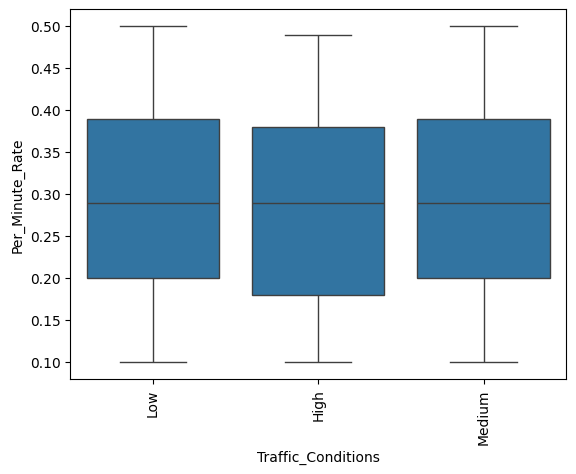

                              sum_sq     df        F    PR(>F)
C(Traffic_Conditions)      94.330112    2.0  0.04735  0.953756
Residual               944301.883010  948.0      NaN       NaN


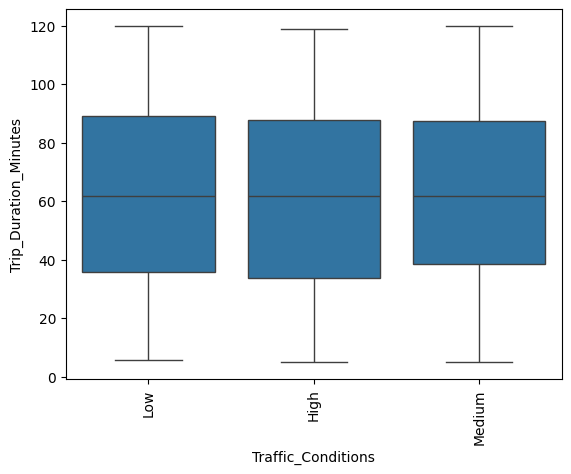

In [64]:
for num in num_col:
    _analyzer.analyze_continous_vs_categories(num,'Traffic_Conditions',df=df_cat_num)

                   sum_sq     df         F    PR(>F)
C(Weather)    1633.993783    2.0  2.127431  0.119711
Residual    364060.235559  948.0       NaN       NaN


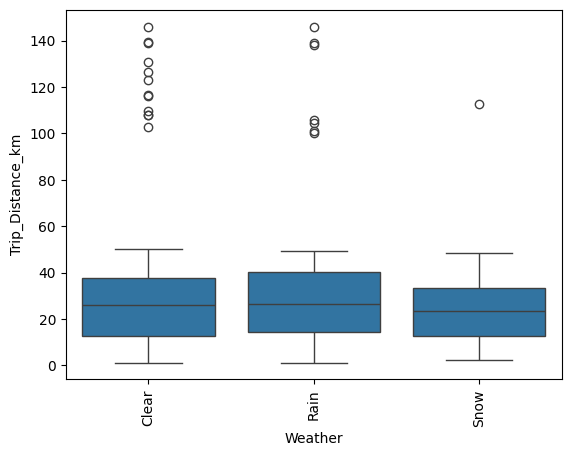

                 sum_sq     df         F    PR(>F)
C(Weather)     0.778843    2.0  0.334676  0.715655
Residual    1103.071841  948.0       NaN       NaN


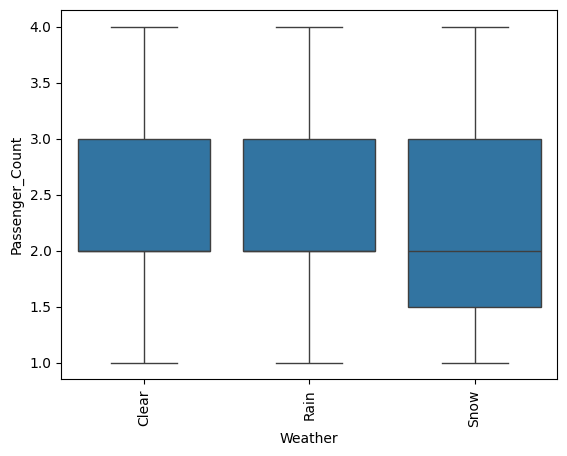

                sum_sq     df         F    PR(>F)
C(Weather)    1.485639    2.0  1.036888  0.354958
Residual    679.141041  948.0       NaN       NaN


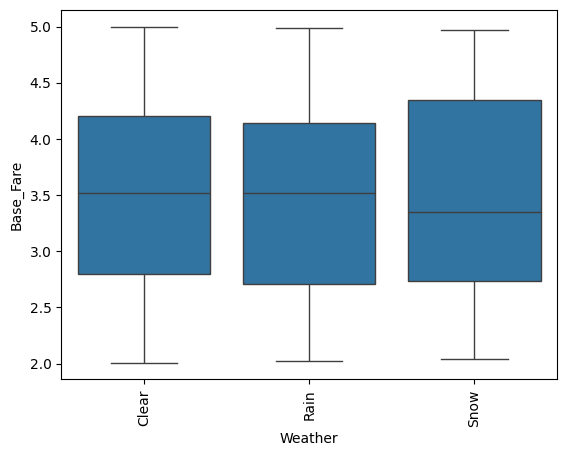

                sum_sq     df         F    PR(>F)
C(Weather)    0.572358    2.0  1.625332  0.197394
Residual    166.918379  948.0       NaN       NaN


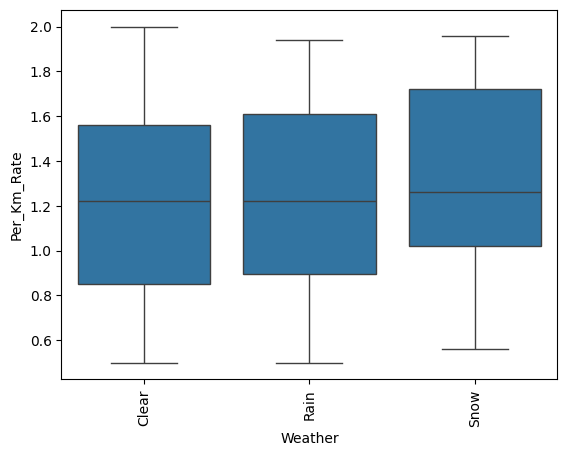

               sum_sq     df         F    PR(>F)
C(Weather)   0.053862    2.0  2.137087  0.118566
Residual    11.946509  948.0       NaN       NaN


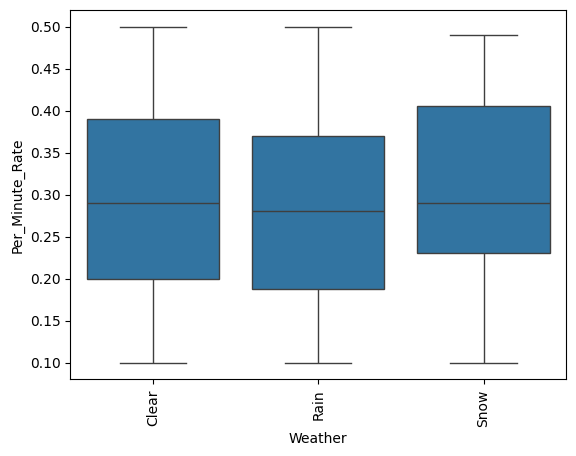

                   sum_sq     df         F    PR(>F)
C(Weather)     879.247733    2.0  0.441713  0.643067
Residual    943516.965388  948.0       NaN       NaN


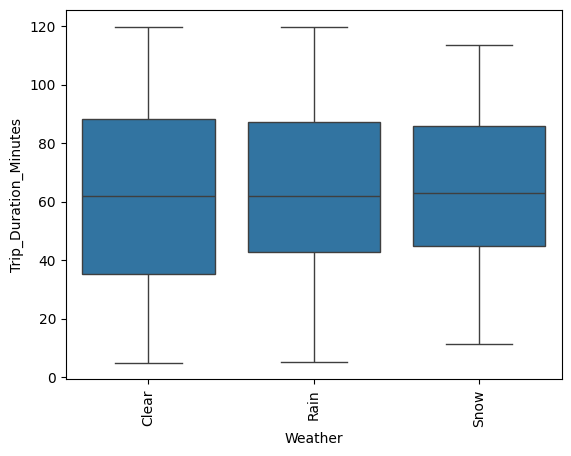

In [65]:
for num in num_col:
    _analyzer.analyze_continous_vs_categories(num,'Weather',df=df_cat_num)

## Detect Outlier and treatment

Seem we have many outlier, we can seperate into 2 case.  
* Keep all outlier and apply RobustScaler
* Remove all outlier and apply MinMaxScaler

### Case 1: Keep all outlier

In [66]:
_df_taxi_in_keep = pd.concat([df_in_cat,df_in_num,df_out],axis=1)

In [67]:
_df_taxi_in_keep.head(2)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,Morning,Weekday,Low,Clear,19.35,3.0,3.56,0.80,0.32,53.82,36.2624
1,Evening,Weekend,High,Clear,36.87,1.0,2.70,1.21,0.15,37.27,52.9032


### Case 2: Remove all oulier

In [68]:
_df_taxi_in_remove_outlier =_df_taxi_in_keep.copy()

In [69]:
uppers,lowers = [],[]
remove_outlier_cols = ['Trip_Distance_km','Passenger_Count','Base_Fare','Per_Km_Rate','Per_Minute_Rate','Trip_Duration_Minutes']
for remove_outlier_col in remove_outlier_cols:
    ouliers_index = _analyzer.check_outlier_of_numerical_variable(
        remove_outlier_col,_df_taxi_in_remove_outlier
    )
    if ouliers_index:
        upper,lower = ouliers_index
        uppers.extend(upper)
        lowers.extend(lower)

variable Trip_Distance_km have 2.103% upper outlier
variable Trip_Distance_km have 0.0% lower outlier
Variable Passenger_Count have no outlier
Variable Base_Fare have no outlier
Variable Per_Km_Rate have no outlier
Variable Per_Minute_Rate have no outlier
Variable Trip_Duration_Minutes have no outlier


In [70]:
ouliers_index = pd.Index(set(uppers+lowers))
ouliers_index

Index([386, 134, 266,  19,  24, 281, 795, 561, 316,  60, 710, 455, 589, 212,
       103, 104, 250, 757, 249, 506],
      dtype='int64')

In [71]:
ouliers_index.size

20

* What should we do with these outlier? should we drop them?

=>Outlier là các giá trị nằm ngoài khoảng phân phối chung, có thể gây sai lệch khi tính trung bình hoặc huấn luyện mô hình. Nên ở chúng ta sẽ thử xoá outlier

In [72]:
_df_taxi_in_remove_outlier.drop(ouliers_index,inplace=True)
_df_taxi_in_remove_outlier.reset_index(drop=True,inplace=True)

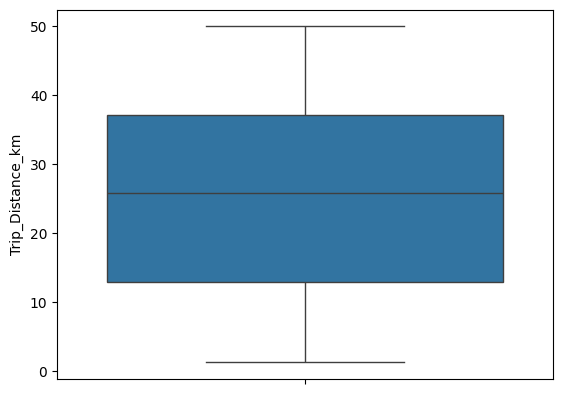

In [73]:
sns.boxplot(y=_df_taxi_in_remove_outlier["Trip_Distance_km"])
plt.show()

In [74]:
_df_taxi_in_remove_outlier.shape

(931, 11)

Finally, we have 2 case
* `_df_taxi_in_keep` which keep all outlier 
* `_df_taxi_in_remove_outlier` which remove outlier all numeric variables

## Data Standardization

In [75]:
_df_taxi_in_remove_outlier.head(5)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,Morning,Weekday,Low,Clear,19.35,3.0,3.56,0.80,0.32,53.82,36.2624
1,Evening,Weekend,High,Clear,36.87,1.0,2.70,1.21,0.15,37.27,52.9032
2,Evening,Weekday,Low,Clear,30.33,4.0,3.48,0.51,0.15,116.81,36.4698
3,Evening,Weekday,High,Clear,25.83,3.0,2.93,0.63,0.32,22.64,15.6180
4,Afternoon,Weekend,Medium,Clear,8.64,2.0,2.55,1.71,0.48,89.33,60.2028


### Scaler for non outlier data

In [76]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [77]:
scaled_data = MinMaxScaler().fit_transform(
    _df_taxi_in_remove_outlier[df_in_num.columns])
scaled_data

array([[0.37161608, 0.66666667, 0.51839465, 0.2       , 0.55      ,
        0.42506314],
       [0.73092699, 0.        , 0.23076923, 0.47333333, 0.125     ,
        0.28093704],
       [0.59680066, 1.        , 0.4916388 , 0.00666667, 0.125     ,
        0.97361317],
       ...,
       [0.13269073, 0.66666667, 0.02341137, 0.85333333, 0.475     ,
        0.42819821],
       [0.95016407, 0.        , 0.22073579, 0.21333333, 0.175     ,
        0.95732822],
       [0.44339623, 0.66666667, 0.77926421, 0.48      , 0.325     ,
        0.21492641]])

In [78]:
scaled_df = pd.DataFrame(scaled_data,columns=df_in_num.columns)
scaled_df =scaled_df.add_prefix('S_')

In [79]:
_df_taxi_in_remove_outlier = pd.concat([_df_taxi_in_remove_outlier,scaled_df],axis=1)
_df_taxi_in_remove_outlier.head(5)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes
0,Morning,Weekday,Low,Clear,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0.371616,0.666667,0.518395,0.200000,0.550,0.425063
1,Evening,Weekend,High,Clear,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.730927,0.000000,0.230769,0.473333,0.125,0.280937
2,Evening,Weekday,Low,Clear,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0.596801,1.000000,0.491639,0.006667,0.125,0.973613
3,Evening,Weekday,High,Clear,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,0.504512,0.666667,0.307692,0.086667,0.550,0.153531
4,Afternoon,Weekend,Medium,Clear,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,0.151969,0.333333,0.180602,0.806667,0.950,0.734303


In [80]:
_df_taxi_in_remove_outlier.tail(2)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes
929,Morning,Weekday,Low,Clear,47.56,1.0,2.67,0.82,0.17,114.94,61.2090,0.950164,0.000000,0.220736,0.213333,0.175,0.957328
930,Morning,Weekend,Medium,Clear,22.85,3.0,4.34,1.22,0.23,29.69,45.4437,0.443396,0.666667,0.779264,0.480000,0.325,0.214926


In [81]:
_df_taxi_in_remove_outlier.shape

(931, 17)

### Scaler for outlier data

In [82]:
_df_taxi_in_keep.head()

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,Morning,Weekday,Low,Clear,19.35,3.0,3.56,0.80,0.32,53.82,36.2624
1,Evening,Weekend,High,Clear,36.87,1.0,2.70,1.21,0.15,37.27,52.9032
2,Evening,Weekday,Low,Clear,30.33,4.0,3.48,0.51,0.15,116.81,36.4698
3,Evening,Weekday,High,Clear,25.83,3.0,2.93,0.63,0.32,22.64,15.6180
4,Afternoon,Weekend,Medium,Clear,8.64,2.0,2.55,1.71,0.48,89.33,60.2028


In [83]:
scaled_outlier_data = RobustScaler().fit_transform(
    _df_taxi_in_keep[df_in_num.columns]  
)
scaled_outlier_data

array([[-0.26234818,  1.        ,  0.02846975, -0.5915493 ,  0.15789474,
        -0.15695461],
       [ 0.44696356, -1.        , -0.58362989, -0.01408451, -0.73684211,
        -0.48003904],
       [ 0.18218623,  2.        , -0.02846975, -1.        , -0.73684211,
         1.0727184 ],
       ...,
       [-0.7340081 ,  1.        , -1.02491103,  0.78873239,  0.        ,
        -0.14992679],
       [ 0.87975709, -1.        , -0.60498221, -0.56338028, -0.63157895,
         1.03621279],
       [-0.12064777,  1.        ,  0.58362989,  0.        , -0.31578947,
        -0.62801367]])

In [84]:
scaled_outlier_df = pd.DataFrame(scaled_outlier_data, columns=df_in_num.columns)
scaled_outlier_df = scaled_outlier_df.add_prefix('S_')

In [85]:
_df_taxi_in_keep = pd.concat([_df_taxi_in_keep, scaled_outlier_df], axis=1)

In [86]:
_df_taxi_in_keep.tail(5)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes
946,Afternoon,Weekend,Medium,Clear,5.49,4.0,2.39,0.62,0.49,58.39,34.4049,-0.823482,2.0,-0.804270,-0.845070,1.052632,-0.067740
947,Night,Weekday,Medium,Clear,45.95,4.0,3.12,0.61,0.29,61.96,62.1295,0.814575,2.0,-0.284698,-0.859155,0.000000,0.001952
948,Morning,Weekday,Low,Rain,7.70,3.0,2.08,1.78,0.29,54.18,33.1236,-0.734008,1.0,-1.024911,0.788732,0.000000,-0.149927
949,Morning,Weekday,Low,Clear,47.56,1.0,2.67,0.82,0.17,114.94,61.2090,0.879757,-1.0,-0.604982,-0.563380,-0.631579,1.036213
950,Morning,Weekend,Medium,Clear,22.85,3.0,4.34,1.22,0.23,29.69,45.4437,-0.120648,1.0,0.583630,0.000000,-0.315789,-0.628014


Finally, we have 2 options:
* `_df_taxi_in_remove_outlier` for non outlier data which apply MinMaxScaler
* `_df_taxi_in_keep` for outlier data which apply RobustScaler

## Feature Engineering

### Encoder for non outlier data

In [87]:
df_in_cat.head(5)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
0,Morning,Weekday,Low,Clear
1,Evening,Weekend,High,Clear
2,Evening,Weekday,Low,Clear
3,Evening,Weekday,High,Clear
4,Afternoon,Weekend,Medium,Clear


In [88]:
df_raw = _df_taxi_in_remove_outlier.copy()

In [89]:
df_raw =pd.get_dummies(
    df_raw,columns=['Time_of_Day','Day_of_Week','Weather'],prefix='E',drop_first=True,dtype=int)

In [90]:
df_raw.head(5)

,Traffic_Conditions,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes,E_Evening,E_Morning,E_Night,E_Weekend,E_Rain,E_Snow
0,Low,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0.371616,0.666667,0.518395,0.200000,0.550,0.425063,0,1,0,0,0,0
1,High,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.730927,0.000000,0.230769,0.473333,0.125,0.280937,1,0,0,1,0,0
2,Low,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0.596801,1.000000,0.491639,0.006667,0.125,0.973613,1,0,0,0,0,0
3,High,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,0.504512,0.666667,0.307692,0.086667,0.550,0.153531,1,0,0,0,0,0
4,Medium,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,0.151969,0.333333,0.180602,0.806667,0.950,0.734303,0,0,0,1,0,0


In [91]:
df_raw['Traffic_Conditions'] = df_raw['Traffic_Conditions'].map({
    'Low': 1,
    'High': 0,
    'Medium': 2
})

In [92]:
df_raw.head(5)

,Traffic_Conditions,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes,E_Evening,E_Morning,E_Night,E_Weekend,E_Rain,E_Snow
0,1,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0.371616,0.666667,0.518395,0.200000,0.550,0.425063,0,1,0,0,0,0
1,0,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.730927,0.000000,0.230769,0.473333,0.125,0.280937,1,0,0,1,0,0
2,1,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0.596801,1.000000,0.491639,0.006667,0.125,0.973613,1,0,0,0,0,0
3,0,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,0.504512,0.666667,0.307692,0.086667,0.550,0.153531,1,0,0,0,0,0
4,2,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,0.151969,0.333333,0.180602,0.806667,0.950,0.734303,0,0,0,1,0,0


### Encoder for outlier data

In [93]:
_df_taxi_in_keep.head(2)

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes
0,Morning,Weekday,Low,Clear,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,-0.262348,1.0,0.02847,-0.591549,0.157895,-0.156955
1,Evening,Weekend,High,Clear,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.446964,-1.0,-0.58363,-0.014085,-0.736842,-0.480039


In [94]:
_df_taxi_in_keep =pd.get_dummies(
    _df_taxi_in_keep,columns=['Time_of_Day','Day_of_Week','Weather'],prefix='E',drop_first=True,dtype=int)

In [95]:
_df_taxi_in_keep.head(5)

,Traffic_Conditions,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes,E_Evening,E_Morning,E_Night,E_Weekend,E_Rain,E_Snow
0,Low,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,-0.262348,1.0,0.028470,-0.591549,0.157895,-0.156955,0,1,0,0,0,0
1,High,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.446964,-1.0,-0.583630,-0.014085,-0.736842,-0.480039,1,0,0,1,0,0
2,Low,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0.182186,2.0,-0.028470,-1.000000,-0.736842,1.072718,1,0,0,0,0,0
3,High,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,0.000000,1.0,-0.419929,-0.830986,0.157895,-0.765642,1,0,0,0,0,0
4,Medium,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,-0.695951,0.0,-0.690391,0.690141,1.000000,0.536262,0,0,0,1,0,0


In [96]:
_df_taxi_in_keep['Traffic_Conditions'] = _df_taxi_in_keep['Traffic_Conditions'].map({
    'Low': 1,
    'High': 0,
    'Medium': 2
})

In [97]:
_df_taxi_in_keep.head(5)

,Traffic_Conditions,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,S_Trip_Distance_km,S_Passenger_Count,S_Base_Fare,S_Per_Km_Rate,S_Per_Minute_Rate,S_Trip_Duration_Minutes,E_Evening,E_Morning,E_Night,E_Weekend,E_Rain,E_Snow
0,1,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,-0.262348,1.0,0.028470,-0.591549,0.157895,-0.156955,0,1,0,0,0,0
1,0,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0.446964,-1.0,-0.583630,-0.014085,-0.736842,-0.480039,1,0,0,1,0,0
2,1,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0.182186,2.0,-0.028470,-1.000000,-0.736842,1.072718,1,0,0,0,0,0
3,0,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,0.000000,1.0,-0.419929,-0.830986,0.157895,-0.765642,1,0,0,0,0,0
4,2,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,-0.695951,0.0,-0.690391,0.690141,1.000000,0.536262,0,0,0,1,0,0


Now, we finished preprocessing data and move to modelling 

## Build model

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Case 1: Modelling for non outlier data with scaler

In [99]:
df_model = df_raw.copy()

In [100]:
feature_cols = [
    'Traffic_Conditions',                 
    'S_Trip_Distance_km','S_Passenger_Count','S_Base_Fare',
    'S_Per_Km_Rate','S_Per_Minute_Rate','S_Trip_Duration_Minutes',
    'E_Evening','E_Morning','E_Night','E_Weekend','E_Rain','E_Snow'
]
feature_cols

['Traffic_Conditions',
 'S_Trip_Distance_km',
 'S_Passenger_Count',
 'S_Base_Fare',
 'S_Per_Km_Rate',
 'S_Per_Minute_Rate',
 'S_Trip_Duration_Minutes',
 'E_Evening',
 'E_Morning',
 'E_Night',
 'E_Weekend',
 'E_Rain',
 'E_Snow']

In [101]:
X1 = df_model[feature_cols]
y1 = df_model['Trip_Price']


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=1)

In [104]:
model = LinearRegression()
model

LinearRegression()

In [105]:
model.fit(X_train,y_train)

LinearRegression()

In [106]:
from sklearn.metrics import r2_score, mean_squared_error

In [107]:
y_hat1 = model.predict(X_test)

In [108]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f"score of training without outlier {train_score}")
print(f"score of test without outlier {test_score}")
train_rmse = mean_squared_error(y_train, model.predict(X_train))
test_rmse  = mean_squared_error(y_test, model.predict(X_test))
print(f"rmse of training without outlier {train_rmse}")
print(f"rmse of test without outlier {test_rmse}")

score of training without outlier 0.8763791243841415
score of test without outlier 0.8489781564140869
rmse of training without outlier 72.46658714581991
rmse of test without outlier 82.0538810869951


In [109]:
min_val = y1.min(); max_val = y1.max(); rng = max_val - min_val
print(f"Trip_Price: Min - {min_val:.4f}, Max - {max_val:.4f}, Range - {rng:.4f}")

Trip_Price: Min - 6.1269, Max - 138.6425, Range - 132.5156


### Case 1.1: Modelling for outlier data with scaler

In [110]:
df_model2 = _df_taxi_in_keep.copy()

In [111]:
X = df_model2[feature_cols]
y = df_model2['Trip_Price']

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [114]:
model = LinearRegression()
model

LinearRegression()

In [115]:
model.fit(X_train,y_train)

LinearRegression()

In [116]:
from sklearn.metrics import r2_score, mean_squared_error

In [117]:
y_hat = model.predict(X_test)

In [118]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)
print(f"score of training without outlier {train_score}")
print(f"score of test without outlier {test_score}")
train_rmse = mean_squared_error(y_train, model.predict(X_train))
test_rmse  = mean_squared_error(y_test, model.predict(X_test))
print(f"rmse of training without outlier {train_rmse}")
print(f"rmse of test without outlier {test_rmse}")

score of training without outlier 0.8547016627707151
score of test without outlier 0.8797324525883928
rmse of training without outlier 207.8076528489682
rmse of test without outlier 294.0743870297314


In [119]:
min_val = y.min(); max_val = y.max(); rng = max_val - min_val
print(f"Trip_Price: Min - {min_val:.4f}, Max - {max_val:.4f}, Range - {rng:.4f}")

Trip_Price: Min - 6.1269, Max - 332.0437, Range - 325.9168


### Case 2: Modelling for non outlier data without scaler

In [120]:
df_model3 = df_raw.copy()

In [121]:
y = df_model3['Trip_Price']
X = df_model3.drop(columns=['Trip_Price'], errors='ignore')

In [122]:
keep_cols = []
for c in X.columns:
    if c.startswith('S_'):
        continue                      # bỏ cột đã scale
    if c.startswith('E_'):
        keep_cols.append(c)           # giữ one-hot
    elif np.issubdtype(X[c].dtype, np.number):
        keep_cols.append(c)

In [123]:
X = X[keep_cols]

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [125]:
model = LinearRegression()
model

LinearRegression()

In [126]:
model.fit(X_train, y_train)

LinearRegression()

In [127]:
y_hat = model.predict(X_test)

In [128]:
acc_train = model.score(X_train,y_train)
acc_test = model.score(X_test,y_test)
train_rmse = mean_squared_error(y_train, model.predict(X_train))
test_rmse  = mean_squared_error(y_test, model.predict(X_test))
print(f"score of training without outlier {train_score}")
print(f"score of test without outlier {test_score}")
print(f"rmse of training without outlier {train_rmse}")
print(f"rmse of test without outlier {test_rmse}")

score of training without outlier 0.8547016627707151
score of test without outlier 0.8797324525883928
rmse of training without outlier 72.46658714581991
rmse of test without outlier 82.05388108699512


In [129]:
min_val = y.min(); max_val = y.max(); rng = max_val - min_val
print(f"Trip_Price: Min - {min_val:.4f}, Max - {max_val:.4f}, Range - {rng:.4f}")

Trip_Price: Min - 6.1269, Max - 138.6425, Range - 132.5156


### 2.1 Modelling for outlier data without scaler

In [130]:
df_model4 = _df_taxi_in_keep.copy()

In [131]:
y = df_model4['Trip_Price']
X = df_model4.drop(columns=['Trip_Price'], errors='ignore')

In [132]:
keep_cols = []
for c in X.columns:
    if c.startswith('S_'):
        continue                      # bỏ cột đã scale
    if c.startswith('E_'):
        keep_cols.append(c)           # giữ one-hot
    elif np.issubdtype(X[c].dtype, np.number):
        keep_cols.append(c)
X = X[keep_cols]

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [134]:
model = LinearRegression()
model

LinearRegression()

In [135]:
model.fit(X_train, y_train)

LinearRegression()

In [136]:
y_hat = model.predict(X_test)

In [137]:
acc_train = model.score(X_train,y_train)
acc_test = model.score(X_test,y_test)
train_rmse = mean_squared_error(y_train, model.predict(X_train))
test_rmse  = mean_squared_error(y_test, model.predict(X_test))
print(f"score of training without outlier {train_score}")
print(f"score of test without outlier {test_score}")
print(f"rmse of training without outlier {train_rmse}")
print(f"rmse of test without outlier {test_rmse}")

score of training without outlier 0.8547016627707151
score of test without outlier 0.8797324525883928
rmse of training without outlier 207.80765284896816
rmse of test without outlier 294.07438702972996


In [138]:
min_val = y.min(); max_val = y.max(); rng = max_val - min_val
print(f"Trip_Price: Min - {min_val:.4f}, Max - {max_val:.4f}, Range - {rng:.4f}")

Trip_Price: Min - 6.1269, Max - 332.0437, Range - 325.9168


## Summary

# |Remove outlier|Apply Scaler|R2 train|rmse train|R2 test|rmse test|
|---|---|---|---|---|---|
|Yes|Yes|0.874|8.604|0.863|8.708|
|No|Yes|0.879|14.269|0.819|16.511|
|Yes|No|0.874|8.604|0.863|8.708|
|No|No|0.879|14.269|0.819|16.511|

* Can we improve R2 score of Non-Outlier + Scaler with polynomial feature or not?

### Additional: Polynomial feature for non outlier data with scaler

In [139]:
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

In [140]:
featuring = PolynomialFeatures()

In [141]:
X_poly = featuring.fit_transform(X1)
X_poly.shape,X1.shape

((931, 105), (931, 13))

In [142]:
X_poly[:5]

array([[1.00000000e+00, 1.00000000e+00, 3.71616079e-01, 6.66666667e-01,
        5.18394649e-01, 2.00000000e-01, 5.50000000e-01, 4.25063137e-01,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.71616079e-01,
        6.66666667e-01, 5.18394649e-01, 2.00000000e-01, 5.50000000e-01,
        4.25063137e-01, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.38098510e-01,
        2.47744053e-01, 1.92643787e-01, 7.43232158e-02, 2.04388843e-01,
        1.57960296e-01, 0.00000000e+00, 3.71616079e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.44444444e-01,
        3.45596433e-01, 1.33333333e-01, 3.66666667e-01, 2.83375425e-01,
        0.00000000e+00, 6.66666667e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.68733012e-01, 1.03678930e-01,
        2.85117057e-01, 2.20350456e-01, 0.00000000e+00, 5.183946

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y1, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((651, 105), (280, 105))

In [145]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((651, 105), (280, 105))

In [146]:
# [127] Fit Linear Regression
model = LinearRegression()
model

LinearRegression()

In [147]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [148]:
from sklearn.metrics import r2_score, mean_squared_error

In [149]:
y_hat_train = model.predict(X_train_scaled)
y_hat_test = model.predict(X_test_scaled)

In [150]:
r2_tr = r2_score(y_train, y_hat_train)
r2_te = r2_score(y_test, y_hat_test)
rmse_tr = mean_squared_error(y_train, y_hat_train)
rmse_te = mean_squared_error(y_test, y_hat_test)

print(f"score of training with scaler poly {r2_tr}")
print(f"score of test with scaler poly {r2_te}")
print(f"rmse of training with scaler poly {rmse_tr}")
print(f"rmse of test with scaler poly {rmse_te}")

score of training with scaler poly 0.9519750641692828
score of test with scaler poly 0.9608567990674514
rmse of training with scaler poly 27.688397970834444
rmse of test with scaler poly 22.977760294303575


In [151]:
import joblib
from sklearn.pipeline import Pipeline
final_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

final_model.fit(X_train, y_train)

joblib.dump(final_model,
            "model/taxi_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

Conclusion: 
* Apply scaler not impact to result of model
* Remove Outlier make model have lower rmse
* Apply Polynomial can improve r2 score and reduce rmse of model

=>Dùng scaler: tác động nhỏ đến R², RMSE.

=>Loại outlier: cải thiện RMSE rõ rệt.

=>Thêm Polynomial: tăng R² và giảm RMSE so với baseline.